In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pykalman import KalmanFilter

In [80]:
raw_df = pd.read_csv('all_data.csv')
print(raw_df.shape)
raw_df.head()

(120, 48)


,pp_id,condition,ts(sec),frame,success,confidence,AU1_InnerBrowRaiser,AU2_OuterBrowRaiser,AU4_BrowLowerer,AU5_UpperLipRaiser,...,move_dist,move_duration,move_speed,scroll_dur,keyPress,press_dur,backsp,backsp_dur,pause_dur,pause_rate
0,pp02,N,60.163,1800.0,1.0,0.979333,0.124822,0.181006,0.251717,0.095600,...,5.659960,0.031436,703.808619,NaN,27.0,0.366753,27.0,0.037037,2.830594,4.717656
1,pp02,N,120.360,3600.0,1.0,0.975500,0.100794,0.032833,0.130733,0.056844,...,15.594104,0.023057,1940.534010,NaN,105.0,0.263460,105.0,0.028000,0.564831,0.941385
2,pp02,N,180.556,5400.0,1.0,0.975056,0.181544,0.064789,0.276167,0.064428,...,19.806823,0.023113,2461.080076,NaN,105.0,0.261484,105.0,0.028778,0.495433,0.825721
3,pp02,N,240.753,7200.0,1.0,0.977056,0.174183,0.089906,0.139750,0.076000,...,5.370893,0.023799,664.848872,NaN,45.0,0.272449,45.0,0.099056,1.512937,2.521561
4,pp02,N,300.950,9000.0,1.0,0.975194,0.141389,0.032494,0.236983,0.069117,...,NaN,NaN,NaN,NaN,131.0,0.318532,131.0,0.055815,0.417129,0.695215


In [81]:
raw_df.describe(include='all')
raw_df.info()
raw_df.isna().sum()

pp_id                        0
condition                    0
ts(sec)                      0
frame                        0
success                      0
confidence                   0
AU1_InnerBrowRaiser          0
AU2_OuterBrowRaiser          0
AU4_BrowLowerer              0
AU5_UpperLipRaiser           0
AU6_CheekRaiser              0
AU7_LidTightener             0
AU9_NoseWringler             0
AU10_UpperLipRaiser          0
AU12_LipCornerPuller         0
AU14_Dimpler                 0
AU15_LipCornerDepressonr     0
AU17_ChinRaiser              0
AU20_LipStretcher            0
AU23_LipTightener            0
AU25_LipsPart                0
AU26_JawDrop                 0
AU45_BlinkInt                0
AUc45_BlinkRate              0
AUc28_LipSuck                0
headOrient_x                 0
headOrient_y                 0
headOrient_z                 0
gazeCenter                   0
gazeUp                       0
gazeDown                     0
gazeRight                    0
gazeLeft

In [72]:
df = raw_df.copy()

### fill in missing values by interpolation (function)

In [110]:
### separated the data in base of person and blok [P=Person][B=Blok][1=data] STILL NEED 2 WORK ON THIS AND APPLY IMPUTATION OF VALUES PP WISE
split_df=[]
pp_df = list(df.groupby("pp_id"))
#pp_df is a list of tuples. pp_df[0] is the first tuple/ holds (ppid, neutral n stress for 1st pp)
#pp_df[0][0]: PPnr (str) and pp_df[0][1]: data (df)
for pp in pp_df:
    split_df.append(list(pp[1].groupby("condition"))) 

In [123]:
(split_df[0][1])

('S',
    pp_id condition      ts(sec)         frame   success  confidence  \
 30  pp02         S   414.381691  12391.634668  1.000000    0.979926   
 31  pp02         S   180.553957   5399.842089  1.000000    0.976449   
 32  pp02         S   180.555582   5399.967672  1.000000    0.978680   
 33  pp02         S   228.429013   6831.493565  1.000000    0.979539   
 34  pp02         S   286.103061   8556.058765  1.000000    0.979550   
 35  pp02         S   345.782738  10340.615593  1.000000    0.979480   
 36  pp02         S   405.873821  12137.454034  1.000000    0.979752   
 37  pp02         S   466.049154  13936.806793  1.000000    0.978883   
 38  pp02         S   526.240935  15736.674288  1.000000    0.977650   
 39  pp02         S   586.436835  17536.647162  1.000000    0.979212   
 40  pp02         S   646.633626  19336.641608  1.000000    0.978333   
 41  pp02         S   706.829776  21136.640471  1.000000    0.979422   
 42  pp02         S   767.026619  22936.640239  1.000000  

In [82]:
def interpolate_missing(df2, col):
        df = df2.copy()
        df[col] = df[col].interpolate()
        # And fill the initial data points if needed:
        df[col] = df[col].fillna(method='bfill')
        return df

In [83]:
for col in ['duration', 'move_dist', 'move_duration', 'move_speed', 'scroll_dur', 'press_dur', 'backsp_dur', 'pause_dur', 'pause_rate']:
    df = interpolate_missing(df, col)

In [84]:
# df = raw_df.dropna() #do sth else with nas. maye 0 in scroll col, wb rest? could use median but dont want to affect the data
# df.isna().sum().sum()
# df.shape

Text(0, 0.5, 'percentage')

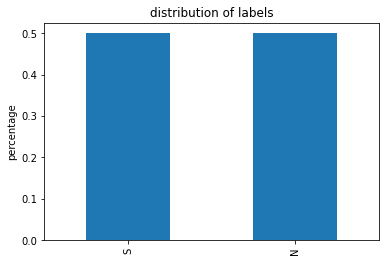

In [22]:
(df['condition'].value_counts()/df.shape[0]).plot(kind='bar',  title = 'distribution of labels')
plt.ylabel('percentage')
# plt.title('distribution of labels')


 COrrelation matrix and cluster map: 


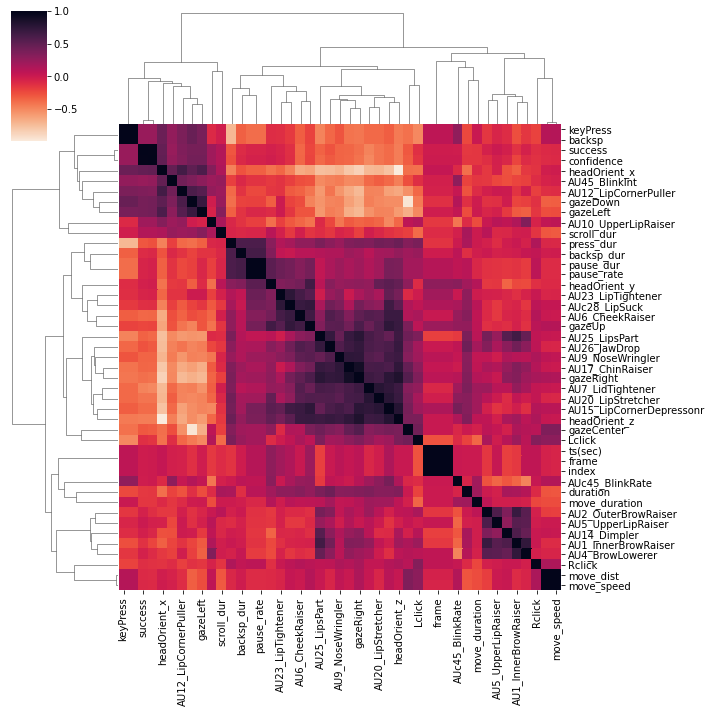

In [26]:
print('\n COrrelation matrix and cluster map: ')
sns.clustermap(df.corr(), cmap="rocket_r", yticklabels=True)

#### defining col groupd

In [133]:
auc_cols = ['AU1_InnerBrowRaiser', 'AU2_OuterBrowRaiser', 'AU4_BrowLowerer',
       'AU5_UpperLipRaiser', 'AU6_CheekRaiser', 'AU7_LidTightener',
       'AU9_NoseWringler', 'AU10_UpperLipRaiser', 'AU12_LipCornerPuller',
       'AU14_Dimpler', 'AU15_LipCornerDepressonr', 'AU17_ChinRaiser',
       'AU20_LipStretcher', 'AU23_LipTightener', 'AU25_LipsPart',
       'AU26_JawDrop', 'AU45_BlinkInt', 'AUc45_BlinkRate', 'AUc28_LipSuck']
head_gaze_cols = ['headOrient_x', 'headOrient_y', 'headOrient_z', 'gazeCenter', 'gazeUp',
       'gazeDown', 'gazeRight', 'gazeLeft']
typing_cols = ['duration',
       'Rclick', 'Lclick', 'move_dist', 'move_duration', 'move_speed',
       'scroll_dur', 'keyPress', 'press_dur', 'backsp', 'backsp_dur',
       'pause_dur', 'pause_rate']
# num_cols = list(df.select_dtypes(include='float').columns)
num_cols = ['AU1_InnerBrowRaiser', 'AU2_OuterBrowRaiser', 'AU4_BrowLowerer', 'AU5_UpperLipRaiser', 'AU6_CheekRaiser', 'AU7_LidTightener', 'AU9_NoseWringler', 'AU10_UpperLipRaiser', 'AU12_LipCornerPuller',
 'AU14_Dimpler','AU15_LipCornerDepressonr', 'AU17_ChinRaiser', 'AU20_LipStretcher', 'AU23_LipTightener', 'AU25_LipsPart', 'AU26_JawDrop', 'AU45_BlinkInt', 'AUc45_BlinkRate', 'AUc28_LipSuck',
 'headOrient_x', 'headOrient_y', 'headOrient_z', 'gazeCenter', 'gazeUp', 'gazeDown', 'gazeRight', 'gazeLeft', 'duration', 'Rclick', 'Lclick', 'move_dist', 'move_duration', 'move_speed',
 'scroll_dur', 'keyPress', 'press_dur', 'backsp', 'backsp_dur', 'pause_dur', 'pause_rate']

In [56]:
df.columns

Index(['pp_id', 'condition', 'ts(sec)', 'frame', 'success', 'confidence',
       'AU1_InnerBrowRaiser', 'AU2_OuterBrowRaiser', 'AU4_BrowLowerer',
       'AU5_UpperLipRaiser', 'AU6_CheekRaiser', 'AU7_LidTightener',
       'AU9_NoseWringler', 'AU10_UpperLipRaiser', 'AU12_LipCornerPuller',
       'AU14_Dimpler', 'AU15_LipCornerDepressonr', 'AU17_ChinRaiser',
       'AU20_LipStretcher', 'AU23_LipTightener', 'AU25_LipsPart',
       'AU26_JawDrop', 'AU45_BlinkInt', 'AUc45_BlinkRate', 'AUc28_LipSuck',
       'headOrient_x', 'headOrient_y', 'headOrient_z', 'gazeCenter', 'gazeUp',
       'gazeDown', 'gazeRight', 'gazeLeft', 'index', 'ts', 'duration',
       'Rclick', 'Lclick', 'move_dist', 'move_duration', 'move_speed',
       'scroll_dur', 'keyPress', 'press_dur', 'backsp', 'backsp_dur',
       'pause_dur', 'pause_rate'],
      dtype='object')

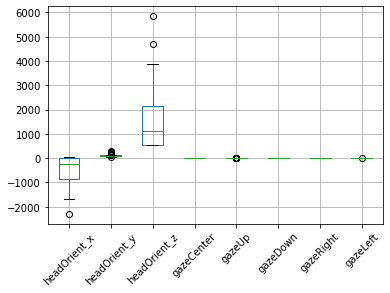

In [38]:
# df[head_gaze_cols].boxplot(by='pp_id')
df[head_gaze_cols].boxplot(rot=45)


# to plot every col as sub plot
# numerical_columns = df.select_dtypes(include='number').columns
# num_cols = len(numerical_columns)

# fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(12, 6))

# for i, col in enumerate(numerical_columns):
#     df.boxplot(column=col, ax=axes[i])
#     axes[i].set_title(col)

# # plt.tight_layout()
# plt.show()



### Kalman filetr to detect and impute outliers (function)

In [57]:
   # Very simple Kalman filter: fill missing values and remove outliers for single attribute.
    # We assume a very simple transition matrix, namely simply a [[1]]. It
    # is however still useful as it is able to dampen outliers and impute missing values. The new
    # values are appended in a new column.
def apply_kalman_filter(df2, col, replaceCol = False):

    df = df2.copy()

    # Initialize the Kalman filter with the trivial transition and observation matrices.
    kf = KalmanFilter(transition_matrices=[[1]], observation_matrices=[[1]])

    numpy_array_state = df[col].values
    numpy_array_state = numpy_array_state.astype(np.float32)
    numpy_matrix_state_with_mask = np.ma.masked_invalid(numpy_array_state)

    # Find the best other parameters based on the data (e.g. Q)
    kf = kf.em(numpy_matrix_state_with_mask, n_iter=5)

    # And apply the filter.
    (new_data, filtered_state_covariances) = kf.filter(numpy_matrix_state_with_mask)

    if replaceCol:
        df[col] = new_data
    else:
        df[col + '_kalman'] = new_data
    return df




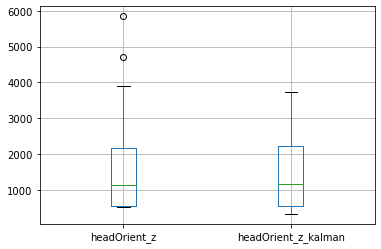

In [58]:
df = apply_kalman_filter(df, 'headOrient_z')
df[['headOrient_z', 'headOrient_z_kalman']].boxplot()

In [86]:
#applying it to all num cols
for col in df.select_dtypes(include='number').columns:
    df = apply_kalman_filter(df, col, replaceCol=True)
    

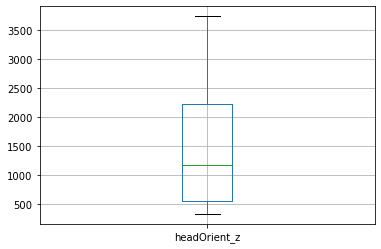

In [87]:
# df[['headOrient_z']].boxplot()

### Clustering
https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

https://www.kaggle.com/code/naiborhujosua/validate-the-clusters-using-silhouette-score

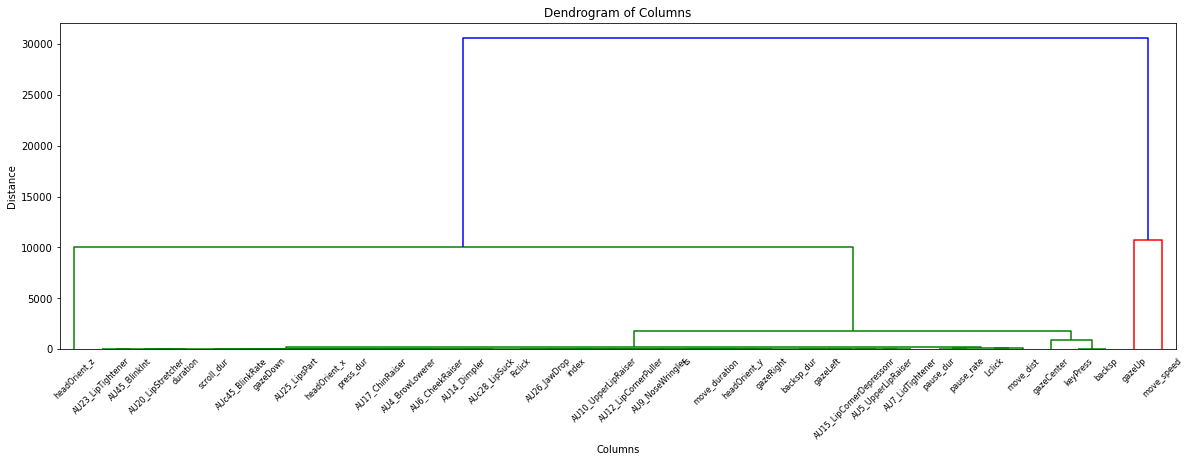

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming your DataFrame is named 'df'
df_transposed = df[num_cols].transpose()  # Transpose the DataFrame to cluster columns instead of rows

# Perform agglomerative clustering
Z = linkage(df_transposed, method='ward')

# Plot the dendrogram
plt.figure(figsize=(20, 6))
dendrogram(Z, labels=df.columns, orientation='top')
plt.xlabel('Columns')
plt.ylabel('Distance')
plt.title('Dendrogram of Columns')
plt.show()


In [175]:
X.astype('float64')

array([[1.23763004e-01, 1.09710014e-01, 1.56282612e-01, ...,
        3.48289593e-02, 4.12677937e-02, 3.83415618e-01],
       [1.51234403e-01, 7.71453071e-02, 6.90289441e-02, ...,
        2.08383820e-02, 2.37065038e-02, 1.36059937e-01],
       [2.31049918e-01, 1.68789994e-01, 2.39078805e-01, ...,
        1.32670828e-01, 1.49395414e-01, 3.19524308e-01],
       ...,
       [3.61719509e-02, 3.11464762e-02, 2.96083458e-02, ...,
        3.77620266e-02, 1.30629720e-02, 8.42612937e-02],
       [1.28263411e+00, 1.15835990e+00, 9.77518576e-01, ...,
        1.45202372e+01, 1.43578453e+01, 1.01177269e+01],
       [2.08542404e+00, 1.89528044e+00, 1.61060439e+00, ...,
        2.39834076e+01, 2.37928608e+01, 1.68505364e+01]])

For n_clusters = 2 The average silhouette_score is : 0.7571674616980923
For n_clusters = 3 The average silhouette_score is : 0.6519282582614496
For n_clusters = 4 The average silhouette_score is : 0.5901883723938597
For n_clusters = 5 The average silhouette_score is : 0.4662157987501028
For n_clusters = 6 The average silhouette_score is : 0.4748413671623262


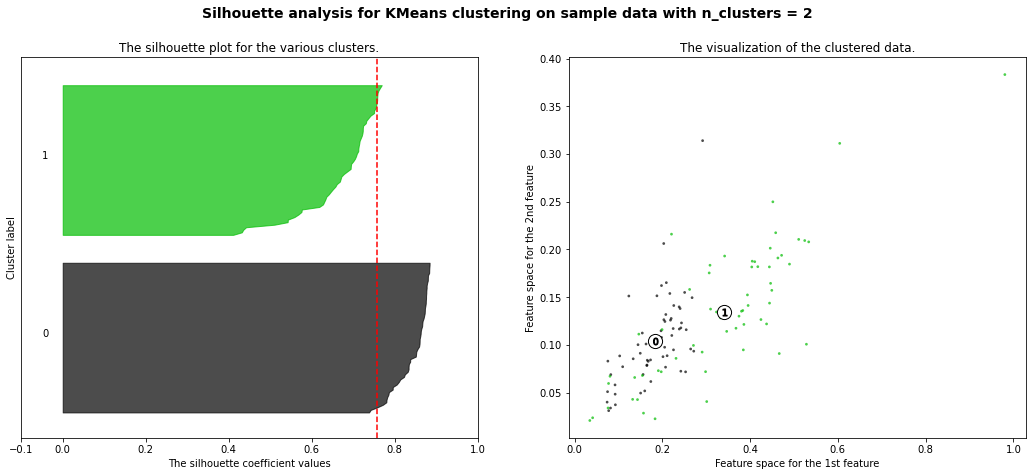

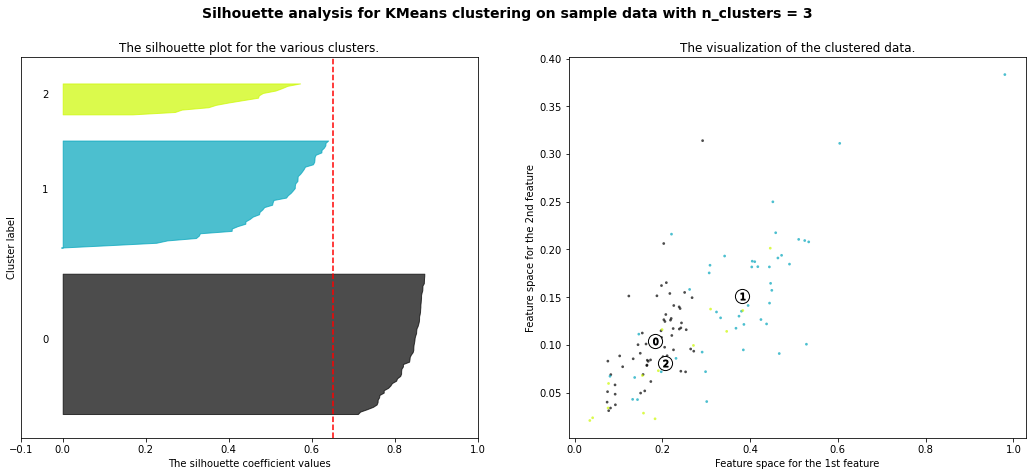

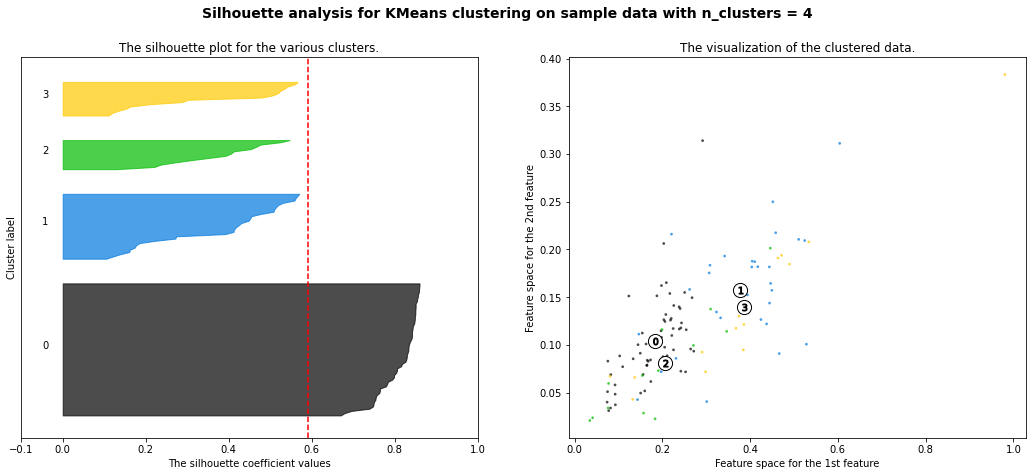

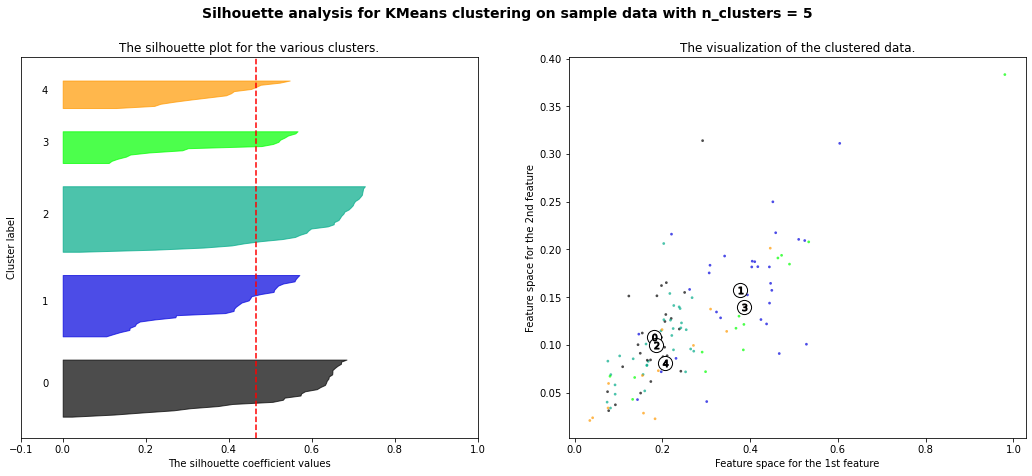

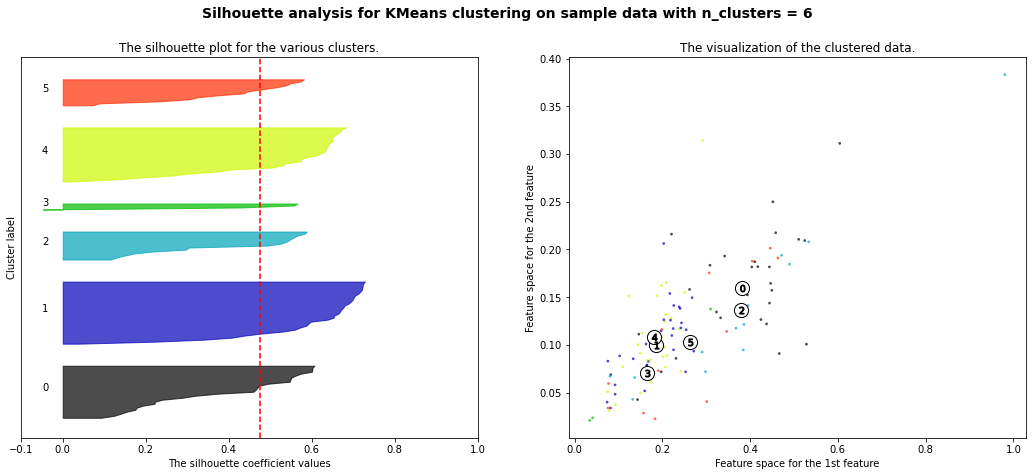

In [179]:
df2 = df[num_cols].copy()
# df_transposed = df2.transpose()
# X = df_transposed.values

X = df2.values
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    ## Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
 # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [166]:
from sklearn.datasets import make_blobs
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=1,
)  # For reproducibility
X


array([[-6.92324165e+00, -1.06695320e+01],
       [-8.63062033e+00, -7.13940564e+00],
       [-9.63048069e+00, -2.72044935e+00],
       [-2.30647659e+00,  5.30797676e+00],
       [-7.57005366e+00, -3.01446491e+00],
       [-1.00051011e+00,  2.77905153e+00],
       [-4.81826839e+00, -2.77214822e+00],
       [-5.33964799e+00, -1.27625764e+00],
       [-7.94308840e+00, -3.89993901e+00],
       [-5.54924525e+00, -3.41298968e+00],
       [-5.14508990e+00, -9.54492198e+00],
       [-7.09669936e+00, -8.04074036e+00],
       [-5.82641512e+00, -1.96346196e+00],
       [-1.83198811e+00,  3.52863145e+00],
       [-7.34267235e+00, -3.16546482e+00],
       [-7.34072825e+00, -6.92427252e+00],
       [-7.94653906e+00, -3.36768655e+00],
       [-8.24598536e+00, -8.61315821e+00],
       [-1.98197711e+00,  4.02243551e+00],
       [-4.35098035e+00, -3.69476678e+00],
       [-1.04768696e+01, -3.60318139e+00],
       [-1.10195984e+01, -3.15882031e+00],
       [-5.17255904e+00, -4.31835971e+00],
       [-2.